#**WebAdOptimization_UpperConfidenceBound_ReinforcementLearning**

### Importing the basic libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math
import random
import io

### Load Dataset from Local Directory

In [2]:
from google.colab import files
uploaded = files.upload()

Saving dataset.csv to dataset.csv


### Importing the dataset

In [3]:
dataset = pd.read_csv('dataset.csv')
print(dataset.shape)
print(dataset.head(5))

(10000, 10)
   Ad 1  Ad 2  Ad 3  Ad 4  Ad 5  Ad 6  Ad 7  Ad 8  Ad 9  Ad 10
0     1     0     0     0     1     0     0     0     1      0
1     0     0     0     0     0     0     0     0     1      0
2     0     0     0     0     0     0     0     0     0      0
3     0     1     0     0     0     0     0     1     0      0
4     0     0     0     0     0     0     0     0     0      0


# *BASIC INFO*

In [4]:
observations = dataset.shape[0]   # number of users
no_of_ads = dataset.shape[1]      # number of ads

# *RANDOM STRATEGY (BASELINE)*

In [5]:
random_total_reward = 0

for n in range(observations):
    ad = random.randrange(no_of_ads)
    reward = dataset.values[n, ad]
    random_total_reward += reward

print("\nTotal Reward (Random Strategy):", random_total_reward)


Total Reward (Random Strategy): 1225


# *Upper Confidence Bound algorithm*

In [6]:
ads_selected = []
ad_counts = [0] * no_of_ads
ad_rewards = [0] * no_of_ads
total_reward = 0

for n in range(observations):
    ad = 0
    max_upper_bound = 0

    for i in range(no_of_ads):
        if ad_counts[i] > 0:
            average_reward = ad_rewards[i] / ad_counts[i]
            delta_i = math.sqrt((3/2) * math.log(n + 1) / ad_counts[i])
            upper_bound = average_reward + delta_i
        else:
            upper_bound = float('inf')  # ensures each ad is selected at least once

        if upper_bound > max_upper_bound:
            max_upper_bound = upper_bound
            ad = i

    # Store selected ad
    ads_selected.append(ad)

    # Update counts and rewards
    ad_counts[ad] += 1
    reward = dataset.values[n, ad]
    ad_rewards[ad] += reward
    total_reward += reward

# *RESULTS*

In [7]:
ctr = total_reward / observations
best_ad = ad_rewards.index(max(ad_rewards))

print("\n===== FINAL RESULTS =====")
print("Total Reward (UCB):", total_reward)
print("Total Reward (Random):", random_total_reward)
print("Improvement over Random: {:.2f}%".format(
    (total_reward - random_total_reward) / random_total_reward * 100
))
print("Click Through Rate (CTR):", ctr)
print("Best Performing Ad Index:", best_ad)
print("Rewards per Ad:", ad_rewards)


===== FINAL RESULTS =====
Total Reward (UCB): 2178
Total Reward (Random): 1225
Improvement over Random: 77.80%
Click Through Rate (CTR): 0.2178
Best Performing Ad Index: 4
Rewards per Ad: [np.int64(120), np.int64(47), np.int64(7), np.int64(38), np.int64(1675), np.int64(1), np.int64(27), np.int64(236), np.int64(20), np.int64(7)]


### Visualizing Result

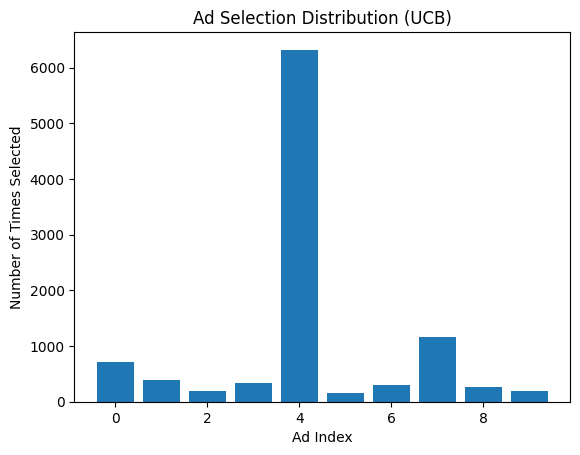

In [8]:
plt.bar(range(no_of_ads), ad_counts)
plt.title('Ad Selection Distribution (UCB)')
plt.xlabel('Ad Index')
plt.ylabel('Number of Times Selected')
plt.show()